# Biomedical Regression: Predicting Drug Response from Gene Expression
## Assessment 2 — Statistical Learning


## Phase 1: Exploratory Data Analysis

In [4]:
%pip install pandas matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('train1.csv')
test = pd.read_csv('test_public.csv')
features = [f'X{i}' for i in range(1, 41)]

print(f"Training: {train.shape}, Test: {test.shape}")
print(f"Labs: {train['group_id'].nunique()}, Samples/lab: {train.groupby('group_id').size().unique()}")
print(f"\nResponse y: mean={train['y'].mean():.2f}, std={train['y'].std():.2f}")
print(f"Missing values: {train.isnull().sum().sum()}")


  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 10.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 13.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.
Training: (4000, 42), Test: (1000, 41)
Labs: 40, Samples/lab: [100]

Response y: mean=14.51, std=4.99
Missing values: 0


In [5]:
# Skewness check
skew = train[features].skew()
print("Max |skewness|:", skew.abs().max(), "- no transformation needed")

# Correlation with y
corr_y = train[features + ['y']].corr()['y'].drop('y').sort_values(key=abs, ascending=False)
print("\nTop feature correlations with y:")
print(corr_y.head(10))

# Batch effects
group_means = train.groupby('group_id')['y'].mean()
print(f"\nBatch effects: lab mean range [{group_means.min():.1f}, {group_means.max():.1f}]")
print(f"Std of lab means: {group_means.std():.2f} vs overall std: {train['y'].std():.2f}")


Max |skewness|: 0.19895241201560301 - no transformation needed

Top feature correlations with y:
X5     0.619043
X6     0.588826
X29    0.576608
X19    0.369725
X36   -0.342910
X13    0.324292
X37    0.276288
X11   -0.145177
X32    0.140839
X22   -0.119677
Name: y, dtype: float64

Batch effects: lab mean range [6.3, 23.0]
Std of lab means: 4.55 vs overall std: 4.99


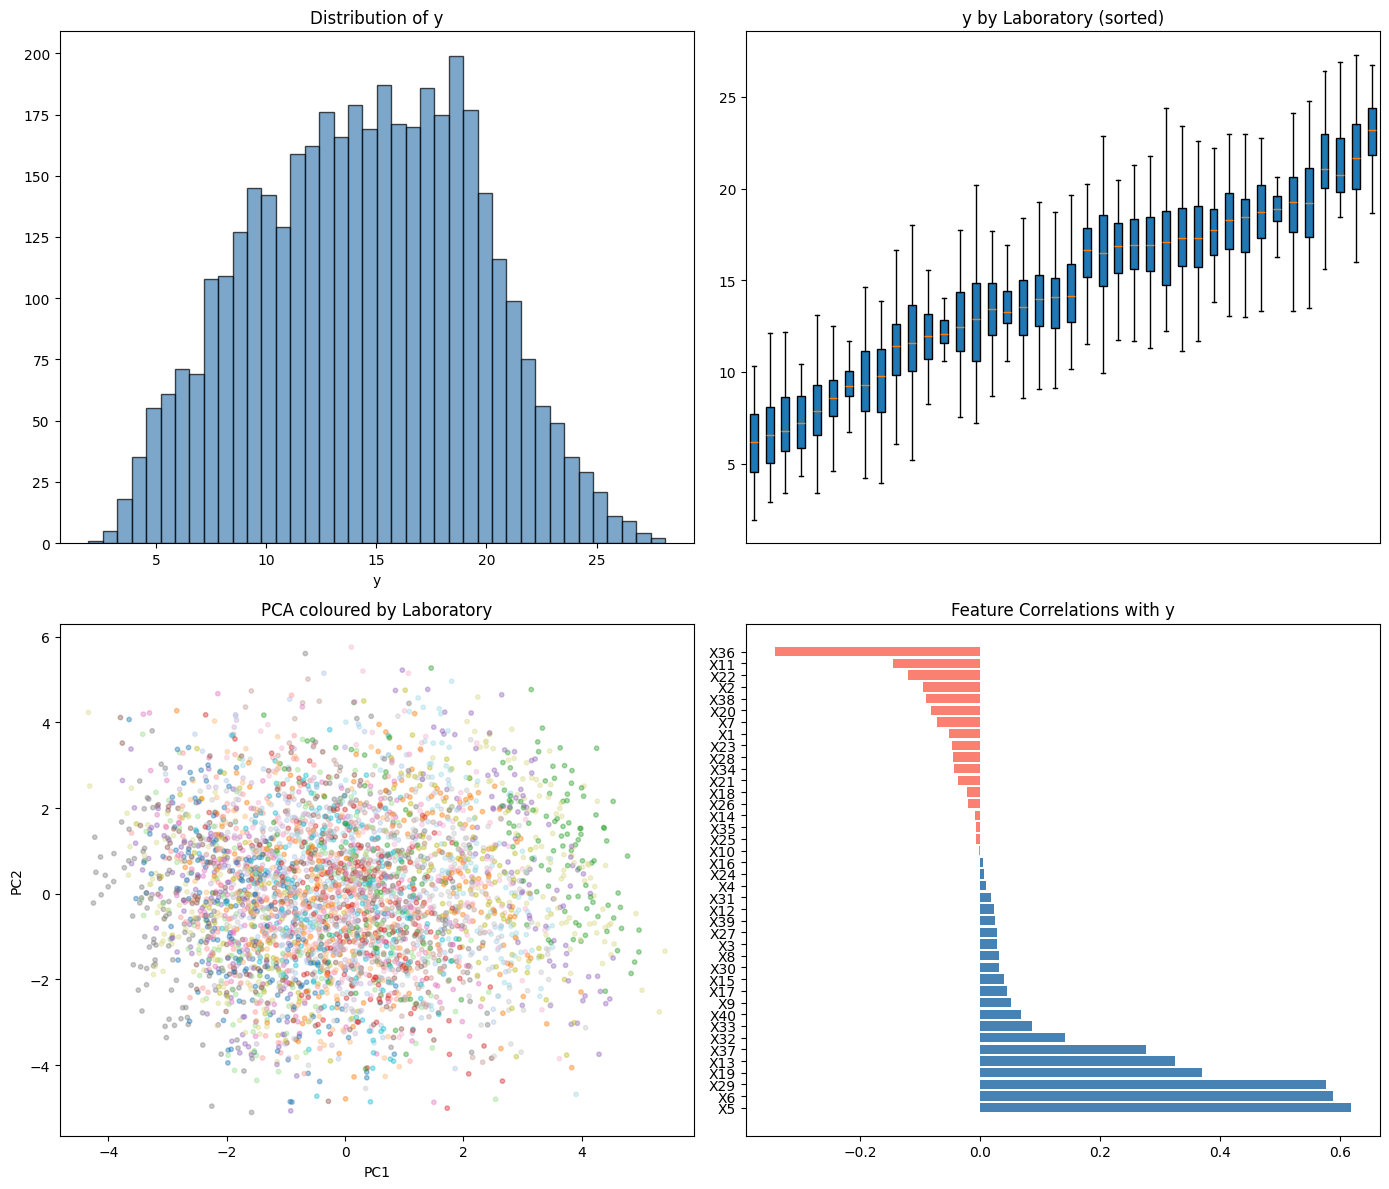

In [6]:
# EDA Figure
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Response distribution
axes[0,0].hist(train['y'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].set_xlabel('y'); axes[0,0].set_title('Distribution of y')

# Batch effects boxplot
group_order = train.groupby('group_id')['y'].mean().sort_values().index
axes[0,1].boxplot([train[train['group_id']==g]['y'].values for g in group_order],
                  patch_artist=True, showfliers=False)
axes[0,1].set_title('y by Laboratory (sorted)'); axes[0,1].set_xticks([])

# PCA
scaler = StandardScaler()
X_sc = scaler.fit_transform(train[features])
pca = PCA(n_components=2).fit_transform(X_sc)
axes[1,0].scatter(pca[:,0], pca[:,1], c=train['group_id'], cmap='tab20', alpha=0.4, s=10)
axes[1,0].set_xlabel('PC1'); axes[1,0].set_ylabel('PC2')
axes[1,0].set_title('PCA coloured by Laboratory')

# Correlations with y
corr_y_all = train[features+['y']].corr()['y'].drop('y').sort_values(ascending=False)
colors_bar = ['steelblue' if v>0 else 'salmon' for v in corr_y_all]
axes[1,1].barh(corr_y_all.index, corr_y_all.values, color=colors_bar)
axes[1,1].set_title('Feature Correlations with y')
plt.tight_layout(); plt.show()


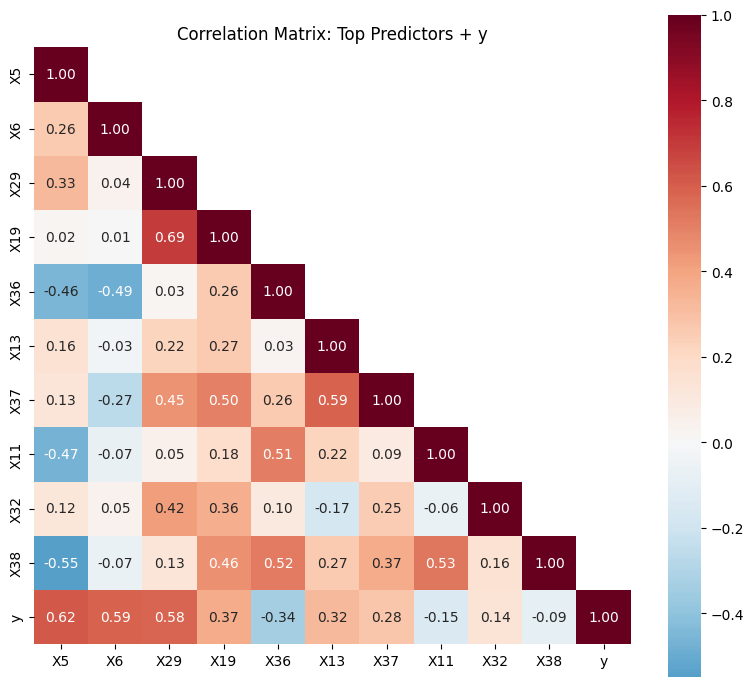

In [7]:
# Correlation heatmap of top features
top = ['X5','X6','X29','X19','X36','X13','X37','X11','X32','X38','y']
fig, ax = plt.subplots(figsize=(8,7))
mask = np.triu(np.ones((len(top),len(top)),dtype=bool), k=1)
sns.heatmap(train[top].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, mask=mask, square=True, ax=ax)
ax.set_title('Correlation Matrix: Top Predictors + y')
plt.tight_layout(); plt.show()


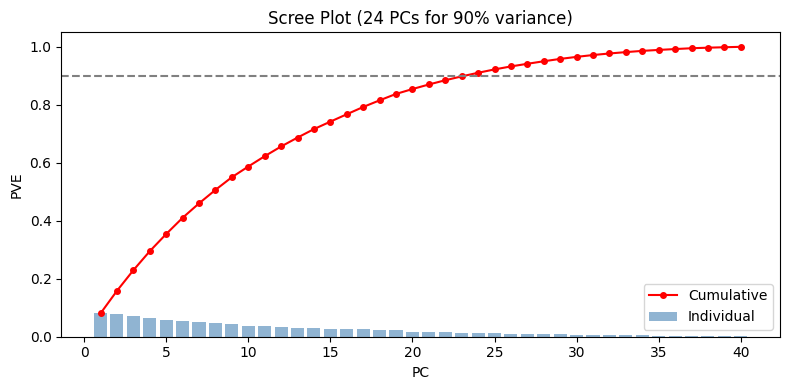

In [8]:
# Scree plot
pca_full = PCA().fit(StandardScaler().fit_transform(train[features]))
cum_pve = np.cumsum(pca_full.explained_variance_ratio_)
n90 = np.argmax(cum_pve >= 0.9) + 1
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(range(1,41), pca_full.explained_variance_ratio_, alpha=0.6, color='steelblue', label='Individual')
ax.plot(range(1,41), cum_pve, 'ro-', markersize=4, label='Cumulative')
ax.axhline(0.9, ls='--', color='grey'); ax.set_xlabel('PC'); ax.set_ylabel('PVE')
ax.set_title(f'Scree Plot ({n90} PCs for 90% variance)'); ax.legend()
plt.tight_layout(); plt.show()


## Phase 2: Model Development

In [9]:
X_train = train[features].values
y_train = train['y'].values
groups = train['group_id'].values
X_test = test[features].values
gkf = GroupKFold(n_splits=10)

# Model 1: Lasso
lasso_alphas = np.logspace(-4, 1, 50)
lasso_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(max_iter=10000))]),
    param_grid={'lasso__alpha': lasso_alphas},
    cv=gkf, scoring='neg_mean_squared_error', n_jobs=-1, return_train_score=True
)
lasso_grid.fit(X_train, y_train, groups=groups)
print(f"Lasso: best α={lasso_grid.best_params_['lasso__alpha']:.4f}, CV MSE={-lasso_grid.best_score_:.4f}")

# Model 2: Ridge
ridge_alphas = np.logspace(-2, 4, 50)
ridge_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())]),
    param_grid={'ridge__alpha': ridge_alphas},
    cv=gkf, scoring='neg_mean_squared_error', n_jobs=-1, return_train_score=True
)
ridge_grid.fit(X_train, y_train, groups=groups)
print(f"Ridge: best α={ridge_grid.best_params_['ridge__alpha']:.2f}, CV MSE={-ridge_grid.best_score_:.4f}")

# PCR comparison
from sklearn.linear_model import LinearRegression
pcr_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('pca', PCA()), ('lr', LinearRegression())]),
    param_grid={'pca__n_components': list(range(1,41))},
    cv=gkf, scoring='neg_mean_squared_error', n_jobs=-1, return_train_score=True
)
pcr_grid.fit(X_train, y_train, groups=groups)
print(f"PCR: best M={pcr_grid.best_params_['pca__n_components']}, CV MSE={-pcr_grid.best_score_:.4f}")


Lasso: best α=0.1456, CV MSE=5.9632
Ridge: best α=339.32, CV MSE=6.3273
PCR: best M=36, CV MSE=6.2418


In [10]:
# Lasso coefficients
lasso_best = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(alpha=lasso_grid.best_params_['lasso__alpha'], max_iter=10000))])
lasso_best.fit(X_train, y_train)
coefs = pd.Series(lasso_best.named_steps['lasso'].coef_, index=features)
print(f"Lasso non-zero features ({(coefs!=0).sum()}/40):")
print(coefs[coefs!=0].sort_values(key=abs, ascending=False))


Lasso non-zero features (7/40):
X6     2.528504
X29    1.793140
X5     1.587035
X37    0.733926
X13    0.388722
X32   -0.349892
X19    0.064126
dtype: float64


## Phase 3: Validation Plots and Model Selection

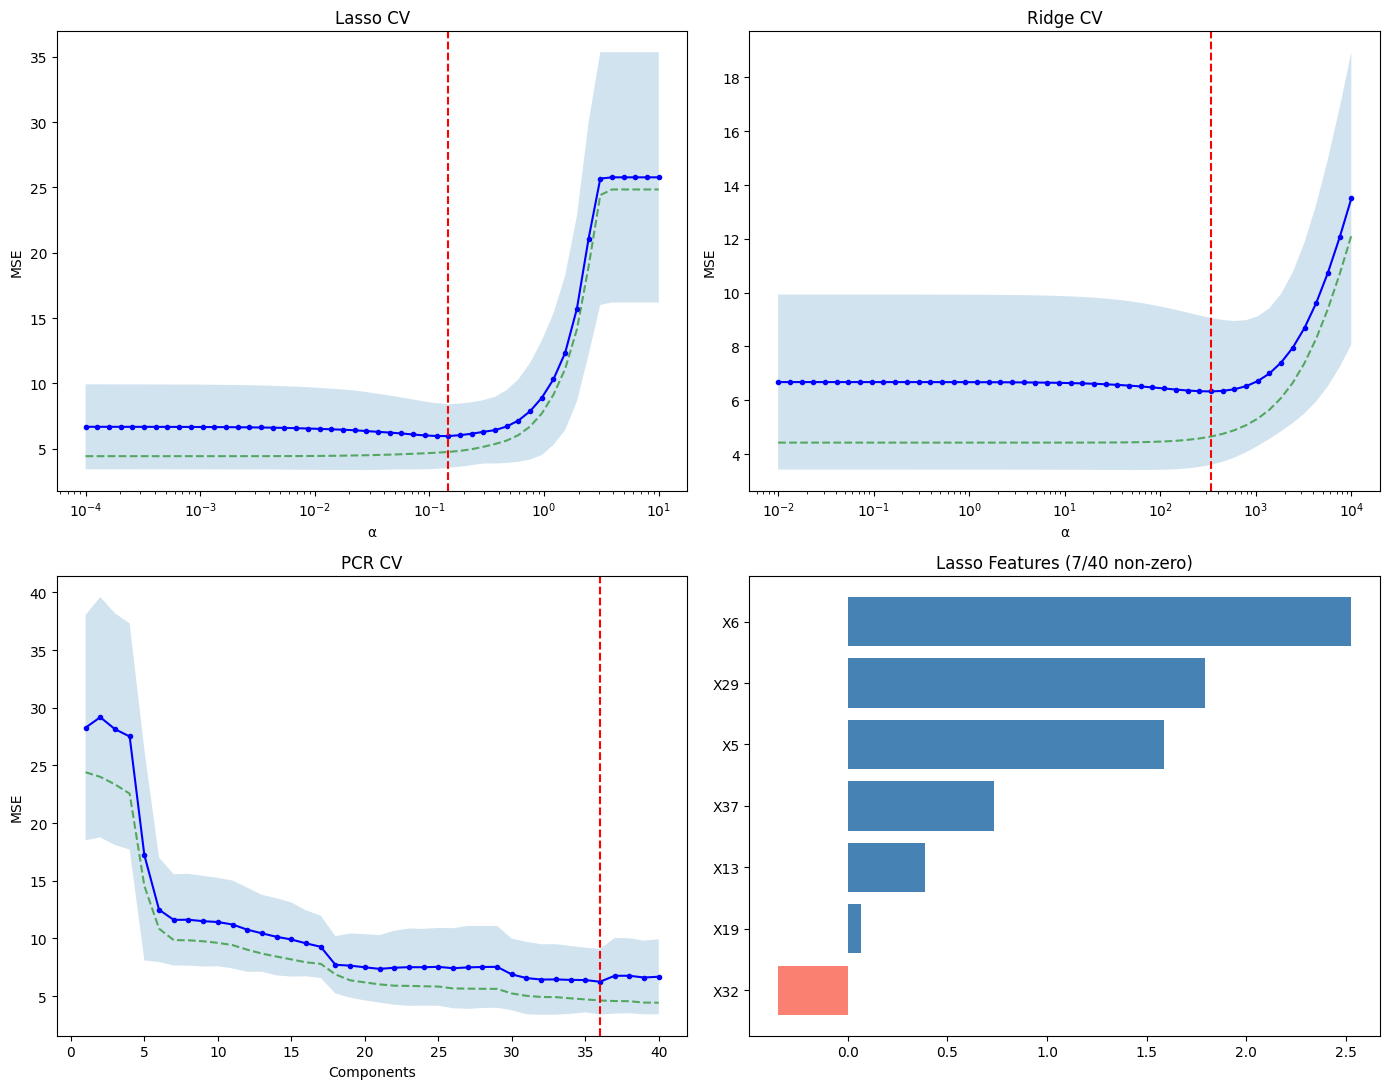

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
# Lasso path
la = np.array(lasso_alphas)
lm = -lasso_grid.cv_results_['mean_test_score']
ls = lasso_grid.cv_results_['std_test_score']
axes[0,0].semilogx(la, lm, 'b-o', ms=3); axes[0,0].fill_between(la, lm-ls, lm+ls, alpha=0.2)
axes[0,0].semilogx(la, -lasso_grid.cv_results_['mean_train_score'], 'g--', alpha=0.6)
axes[0,0].axvline(lasso_grid.best_params_['lasso__alpha'], color='r', ls='--')
axes[0,0].set_xlabel('α'); axes[0,0].set_ylabel('MSE'); axes[0,0].set_title('Lasso CV')

# Ridge path
ra = np.array(ridge_alphas)
rm = -ridge_grid.cv_results_['mean_test_score']
rs = ridge_grid.cv_results_['std_test_score']
axes[0,1].semilogx(ra, rm, 'b-o', ms=3); axes[0,1].fill_between(ra, rm-rs, rm+rs, alpha=0.2)
axes[0,1].semilogx(ra, -ridge_grid.cv_results_['mean_train_score'], 'g--', alpha=0.6)
axes[0,1].axvline(ridge_grid.best_params_['ridge__alpha'], color='r', ls='--')
axes[0,1].set_xlabel('α'); axes[0,1].set_ylabel('MSE'); axes[0,1].set_title('Ridge CV')

# PCR
nc = np.arange(1,41)
pm = -pcr_grid.cv_results_['mean_test_score']
ps = pcr_grid.cv_results_['std_test_score']
axes[1,0].plot(nc, pm, 'b-o', ms=3); axes[1,0].fill_between(nc, pm-ps, pm+ps, alpha=0.2)
axes[1,0].plot(nc, -pcr_grid.cv_results_['mean_train_score'], 'g--', alpha=0.6)
axes[1,0].axvline(pcr_grid.best_params_['pca__n_components'], color='r', ls='--')
axes[1,0].set_xlabel('Components'); axes[1,0].set_ylabel('MSE'); axes[1,0].set_title('PCR CV')

# Lasso coefficients
nz = coefs[coefs!=0].sort_values()
axes[1,1].barh(nz.index, nz.values, color=['steelblue' if v>0 else 'salmon' for v in nz])
axes[1,1].set_title(f'Lasso Features ({len(nz)}/40 non-zero)')
plt.tight_layout(); plt.show()


## Phase 4: Final Predictions

In [12]:
# Refit final model on all training data
best_alpha = lasso_grid.best_params_['lasso__alpha']
final_model = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(alpha=best_alpha, max_iter=10000))])
final_model.fit(X_train, y_train)
print(f"Training R² = {1 - mean_squared_error(y_train, final_model.predict(X_train))/np.var(y_train):.4f}")
print(f"Training MSE = {mean_squared_error(y_train, final_model.predict(X_train)):.4f}")

# Generate predictions
y_hat = final_model.predict(X_test)
predictions = pd.DataFrame({'obs_id': test['obs_id'], 'y_hat': y_hat})
predictions.to_csv('predictions.csv', index=False)
print(f"\nPredictions saved: {len(predictions)} rows")
print(predictions.describe())


Training R² = 0.8069
Training MSE = 4.8070

Predictions saved: 1000 rows
            obs_id        y_hat
count  1000.000000  1000.000000
mean    500.500000    14.225098
std     288.819436     5.127695
min       1.000000     4.640474
25%     250.750000     9.807128
50%     500.500000    13.516943
75%     750.250000    18.392950
max    1000.000000    25.274990
